In [1]:
import sleap
import sys
import json
import os
import pandas as pd
import joblib

sys.path.append('..')
from python.polygon_based_correction import *
from python.animation import *
from eval.eval import *
from python.dataset_conversion import *
from python.misprediction_classifier import *

sleap.versions()
sleap.system_summary()

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedShuffleSplit
from sklearn.metrics import accuracy_score, classification_report
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

SLEAP: 1.4.1
TensorFlow: 2.7.0
Numpy: 1.21.5
Python: 3.7.12
OS: Linux-6.8.0-51-generic-x86_64-with-debian-trixie-sid
GPUs: 2/2 available
  Device: /physical_device:GPU:0
         Available: True
       Initialized: False
     Memory growth: None
  Device: /physical_device:GPU:1
         Available: True
       Initialized: False
     Memory growth: None


In [2]:
dataset_path = '/home/mingxiao/Desktop/jellyfish/video/video_1_clips/correction_test/a1_1h_1m_w_scores.slp'
dataset = sleap.load_file(dataset_path)
print(dataset)

Labels(labeled_frames=9000, videos=1, skeletons=1, tracks=17)


In [4]:
multi_4k_points_path = '/home/mingxiao/Desktop/jellyfish/label/multifish/predictions/multifish_animal_1_v10_predicted_points_with_score.npy'
multi_4k_points = np.load(multi_4k_points_path)
print(multi_4k_points.shape)
start_idx = 150 * 60 * 60
end_idx = 150 * 60 * 61
multi_pts_clip = multi_4k_points[start_idx:end_idx]
print(multi_pts_clip.shape)

(3240000, 17, 3)
(9000, 17, 3)


In [5]:
a1_pts = multi_pts_clip[:, :, :2]
a1_scores = multi_pts_clip[:, :, 2]

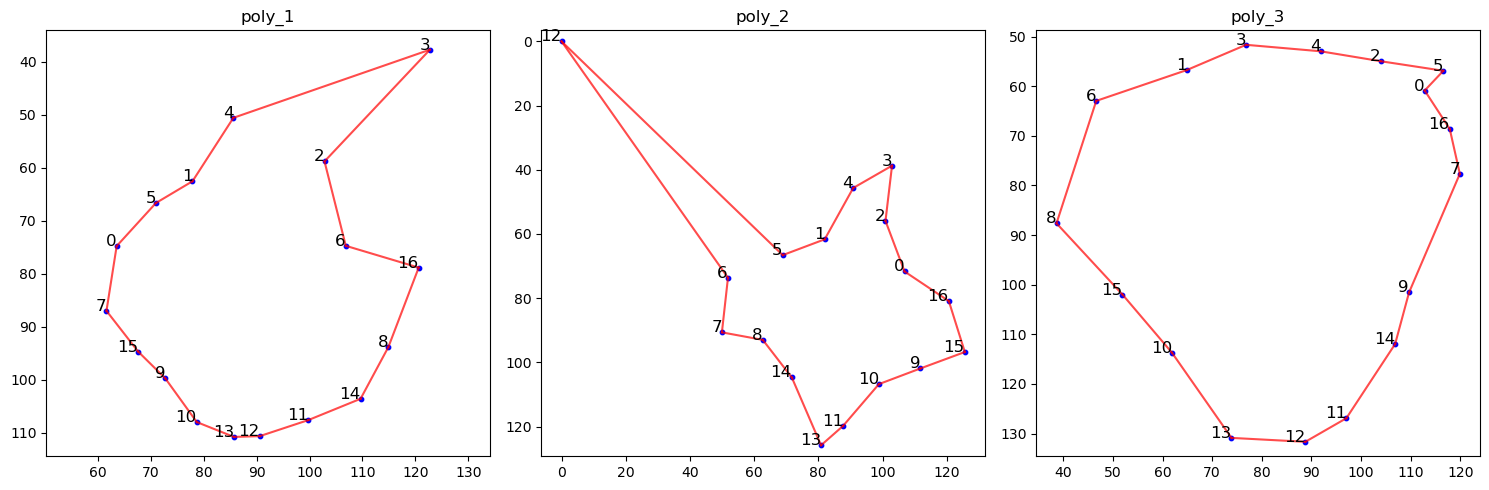


Total edge lengths:
poly_1: 231.676
poly_2: 422.117
poly_3: 257.237


In [15]:
frame_indices = [19, 32, 51]
plot_multiframe_polygons(a1_pts[frame_indices])

# ID mispredicted points

1. prediction score < 0.6 and nn to prev frame > 5 pixels
2. when nn distance < 5 pixels, keep the one with higher prediction score
3. check the angle between a point and its two nearest neighbor? and distance

use SVM (or anything that does classification) to classify? 

input features
- prediction score
- angle
- 2 nn distance (current frame)
- nn distance (prev frame) -> this needs the points to be contiguous in time

determine whether a point is "correct": nn dist to manulaay labeled frame < 5 pixels

## nn angle

In [34]:
def plot_nn_angle(frame_pts, poly_constructor=poly_4):
    poly_order = poly_constructor(frame_pts)
    frame_pts = frame_pts[poly_order]
    pt_cnt = frame_pts.shape[0]
    angles = calculate_polygon_angles(frame_pts)
    print(' '.join([f"{angle:.0f}" for angle in np.sort(angles)]))
    # print(f'min nn angle: {np.min(angles):.2f}, max nn angle: {np.max(angles):.2f}')
    plt.figure(figsize=(6, 4))
    plt.hist(angles, bins=pt_cnt)
    plt.xlabel('Nearest Neighbor Angle')
    plt.ylabel('Count')
    plt.show()

28 86 133 140 142 147 148 157 163 163 173 173 176 190 206 237 239


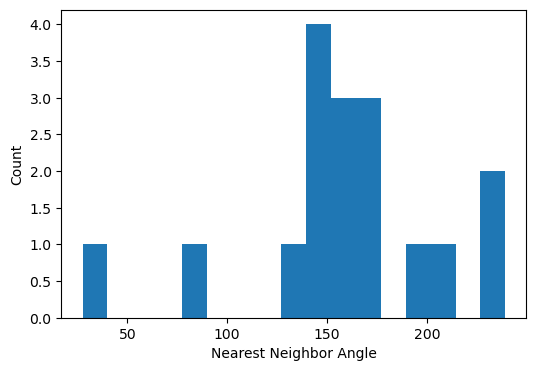

In [35]:
frame_idx = 19
plot_nn_angle(a1_pts[frame_idx])

11 53 72 93 94 141 149 172 180 194 207 209 216 220 221 222 245


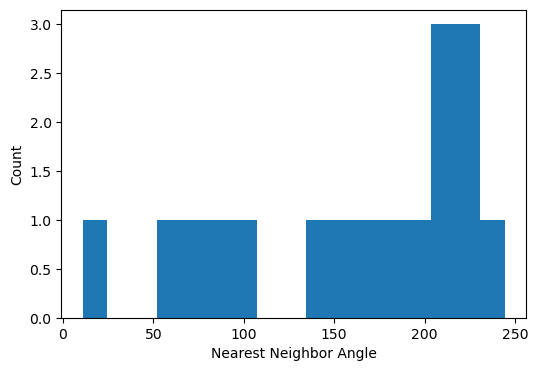

In [36]:
frame_idx = 32
plot_nn_angle(a1_pts[frame_idx])

55 119 127 128 144 147 152 153 160 162 176 181 182 184 185 188 256


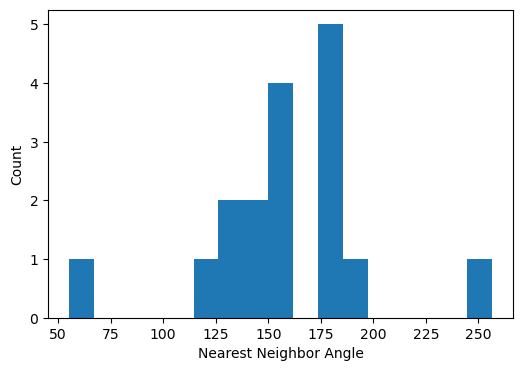

In [37]:
frame_idx = 51
plot_nn_angle(a1_pts[frame_idx])

## nn distance

In [16]:
def plot_nn_dist(frame_pts):
    pt_cnt = frame_pts.shape[0]
    nn_dists = []
    for i in range(pt_cnt):
        pt = frame_pts[i]
        dists = np.linalg.norm(frame_pts[np.arange(pt_cnt) != i] - pt, axis=1)
        nn_dists.append(np.min(dists))
    nn_dists = np.array(nn_dists)
    print(f'min nn dist: {np.min(nn_dists):.2f}, max nn dist: {np.max(nn_dists):.2f}')
    plt.hist(nn_dists, bins=pt_cnt)
    plt.xlabel('Nearest Neighbor Distance')
    plt.ylabel('Count')
    plt.gca().yaxis.set_major_locator(plt.MaxNLocator(integer=True))  # Force integer y-axis ticks
    plt.show()

min nn dist: 4.07, max nn dist: 21.01


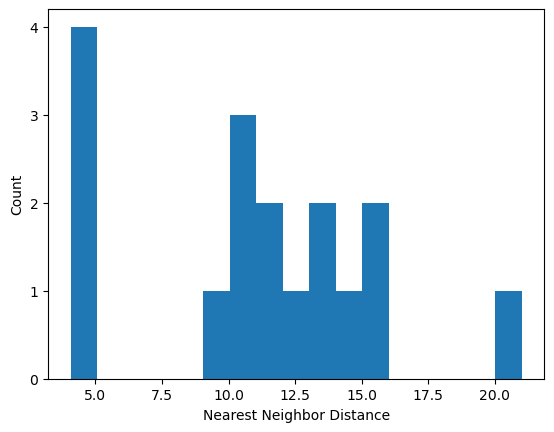

In [18]:
frame_idx = 50
plot_nn_dist(multi_pts_clip[frame_idx, :, :2])

min nn dist: 5.47, max nn dist: 19.55


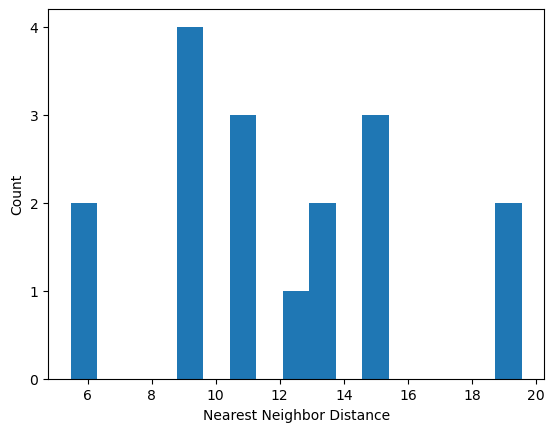

In [19]:
frame_idx = 51
plot_nn_dist(multi_pts_clip[frame_idx, :, :2])

min nn dist: 8.58, max nn dist: 19.83


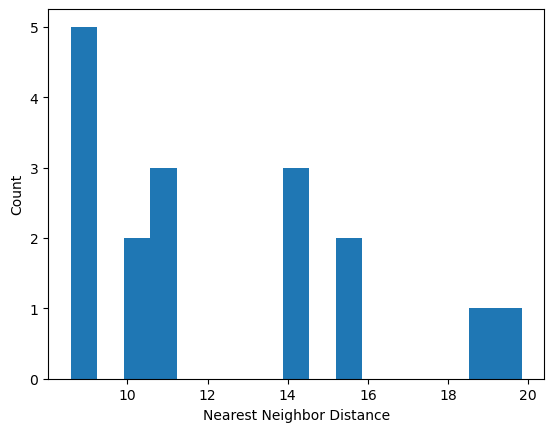

In [20]:
frame_idx = 53
plot_nn_dist(multi_pts_clip[frame_idx, :, :2])

min nn dist: 4.73, max nn dist: 24.72


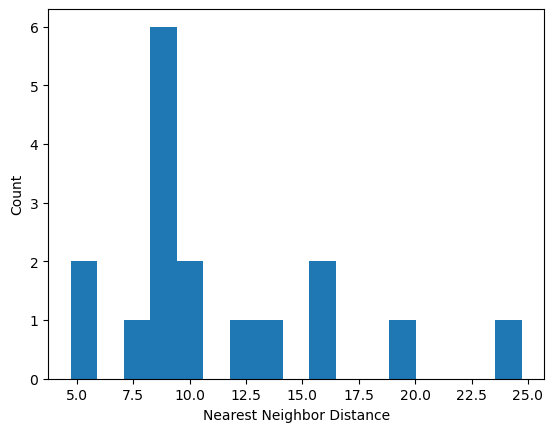

In [23]:
frame_idx = 56
plot_nn_dist(multi_pts_clip[frame_idx, :, :2])

min nn dist: 5.21, max nn dist: 18.02


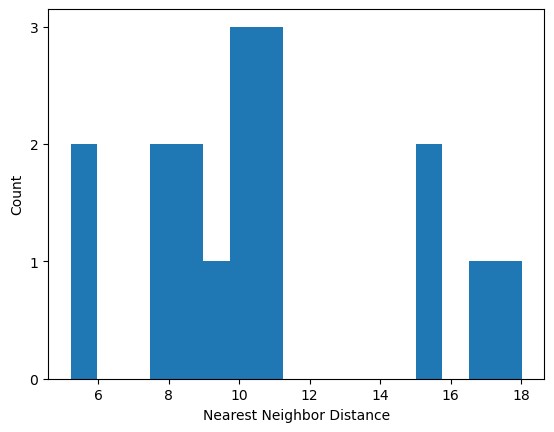

In [28]:
frame_idx = 61
plot_nn_dist(multi_pts_clip[frame_idx, :, :2])

min nn dist: 4.93, max nn dist: 14.59


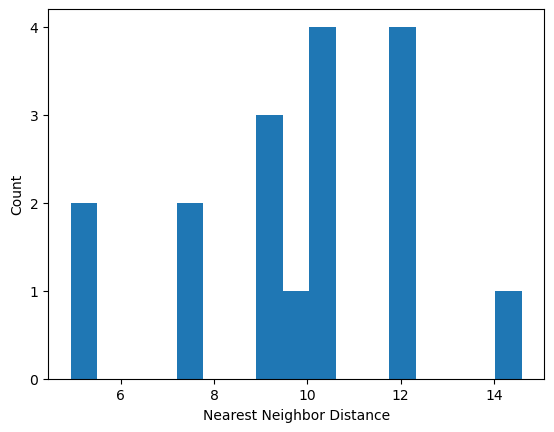

In [30]:
frame_idx = 66
plot_nn_dist(multi_pts_clip[frame_idx, :, :2])

## generate dataset for classification training

In [2]:
cont_start_idx = 479850
cont_end_idx = cont_start_idx + 9000

In [3]:
new_4k_dataset_path = '/home/mingxiao/Desktop/jellyfish/label/multifish/multifish_animal_1_v11.slp'
new_4k_dataset = sleap.load_file(new_4k_dataset_path)
print(new_4k_dataset)
new_4k_pts = get_all_untracked_points_from_lbfs(new_4k_dataset.labeled_frames, interpolate=False, reorder=False, use_labeled_only=True)
new_lbf_indices = np.array([lbf.frame_idx for lbf in new_4k_dataset.labeled_frames])
print(new_4k_pts.shape)
predicted_pts_path = '/home/mingxiao/Desktop/jellyfish/label/multifish/predictions/multifish_animal_1_v10_predicted_points.npy'
predicted_pts = np.load(predicted_pts_path)[new_lbf_indices]
print(predicted_pts.shape)
gt_pts = new_4k_pts

Labels(labeled_frames=4149, videos=1, skeletons=1, tracks=17)
all_untracked_points shape: (4149, 17, 2)


4149it [00:04, 923.53it/s]


Missing point count: 0
(4149, 17, 2)
(4149, 17, 2)


In [4]:
pred_pts_score_path = '/home/mingxiao/Desktop/jellyfish/label/multifish/predictions/multifish_animal_1_v10_predicted_points_with_score.npy'
pred_pts_score = np.load(pred_pts_score_path)[new_lbf_indices]

In [5]:
cont_indices = (new_lbf_indices >= cont_start_idx) & (new_lbf_indices < cont_end_idx)
cont_gt_pts = gt_pts[cont_indices]
cont_pred_pts = predicted_pts[cont_indices]
cont_pred_pts_score = pred_pts_score[cont_indices]
print(cont_gt_pts.shape, cont_pred_pts.shape)

(2515, 17, 2) (2515, 17, 2)


In [37]:
def get_classification_dataset(pred_pts, gt_pts):
    """
    Args:
        pred_pts (np.array): (frame_cnt, pt_cnt, 3); predicted points in contiguous frames, 
                             where the last column is prediction score 
        gt_pts (np.array): (frame_cnt, pt_cnt, 2); labeled points in contiguous frames

    Returns:
        features: ((frame_cnt - 1) * pt_cnt, 4); 
                  4 features: prediction score, angle, 2 nn distance (current frame); nn distance (prev frame)
        labels: ((frame_cnt - 1) * pt_cnt, ); 1 = correct, 0 = incorrect 
    """
    pred_pts_score = pred_pts[1:, :, 2]
    pred_pts_angle = calculate_polygon_angles(pred_pts[1:, :, :2])
    pred_pts_2nn_dist = get_2nn_dist_multi_frame(pred_pts[1:, :, :2])
    pred_pts_prev_nn_dist = get_nn_dist_prev_frame(pred_pts[:, :, :2])
    features = np.stack([pred_pts_score, pred_pts_angle, pred_pts_2nn_dist, pred_pts_prev_nn_dist], axis=2)
    labels = get_labels(pred_pts[1:, :, :2], gt_pts[1:])
    nan_mask = np.isnan(features).any(axis=2)
    features = features[~nan_mask].reshape(-1, 4)
    labels = labels[~nan_mask]
    return features, labels

In [35]:
labels = get_labels(cont_pred_pts, cont_gt_pts)
print(labels.shape)
print(f'{int(labels.sum())} out of {2515 * 17} ({labels.sum() / (2515 * 17):.2%}) points are correctly predicted')

cont_features, cont_labels = get_classification_dataset(cont_pred_pts_score, cont_gt_pts)

(2515, 17)
39216 out of 42755 (91.72%) points are correctly predicted


../eval/eval.py:309: RuntimeWarning: invalid value encountered in true_divide
  v2 /= np.linalg.norm(v2)
../eval/eval.py:308: RuntimeWarning: invalid value encountered in true_divide
  v1 /= np.linalg.norm(v1)


nan_mask.shape: (2514, 17)
features.shape: (2514, 17, 4)
labels.shape: (2514, 17)
features.shape: (41910, 4)
labels.shape: (41910,)


In [36]:
cont_labels.shape, cont_features.shape

((41910,), (41910, 4))

In [8]:
feature_cnt = 4
X = cont_features.reshape(-1, feature_cnt)
y = cont_labels.flatten()
print(X.shape, y.shape)

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.1)

(41910, 4) (41910,)


## train a classifier

### SVM

#### default params

In [43]:
# Train an SVM classifier
svm_clf = SVC(kernel='rbf', C=1.0, gamma='scale')  # RBF kernel for non-linearity
svm_clf.fit(X_train, y_train)

# Predict on test set
y_pred = svm_clf.predict(X_test)

# Evaluate performance
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.937007874015748
              precision    recall  f1-score   support

         0.0       1.00      0.05      0.10       279
         1.0       0.94      1.00      0.97      3912

    accuracy                           0.94      4191
   macro avg       0.97      0.53      0.53      4191
weighted avg       0.94      0.94      0.91      4191



#### grid search 1

In [14]:
C_range = np.logspace(-2, 2, 5)
gamma_range = np.logspace(-2, 2, 5)
param_grid = dict(gamma=gamma_range, C=C_range)
cv = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=42)
grid = GridSearchCV(SVC(), param_grid=param_grid, cv=cv)
grid.fit(X_scaled, y)

print(
    "The best parameters are %s with a score of %0.2f"
    % (grid.best_params_, grid.best_score_)
)

# Predict on test set
y_pred = grid.predict(X_test)

# Evaluate performance
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

The best parameters are {'C': 0.1, 'gamma': 0.1} with a score of 0.94
Accuracy: 0.9372952737482452
              precision    recall  f1-score   support

         0.0       1.00      0.29      0.45       376
         1.0       0.94      1.00      0.97      3898

    accuracy                           0.94      4274
   macro avg       0.97      0.64      0.71      4274
weighted avg       0.94      0.94      0.92      4274



#### grid search 2

In [24]:
test_arr = np.arange(24).reshape(4, 3, 2)
print(test_arr.shape)
# mask = (test_arr > 10).any(axis=2)
mask = (test_arr > 10).any(axis=2)[:, :, np.newaxis]  # Shape: (4, 3, 1)
mask = np.broadcast_to(mask, test_arr.shape)  # Shape: (4, 3, 2)
print(mask.shape)
test_arr[mask].shape

(4, 3, 2)
(4, 3, 2)


(14,)

In [10]:
from sklearn.metrics import make_scorer, recall_score

# Create a custom scorer that focuses on recall for class 0
recall_0_scorer = make_scorer(recall_score, pos_label=0)

In [27]:
C_range = np.logspace(-2, 2, 5)
gamma_range = np.logspace(-2, 2, 5)
param_grid = dict(gamma=gamma_range, C=C_range)
cv = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=42)
grid = GridSearchCV(SVC(), param_grid=param_grid, cv=cv, scoring=recall_0_scorer)
grid.fit(X_scaled, y)

print(
    "The best parameters are %s with a score of %0.2f"
    % (grid.best_params_, grid.best_score_)
)

# Predict on test set
y_pred = grid.predict(X_test)

# Evaluate performance
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

The best parameters are {'C': 100.0, 'gamma': 10.0} with a score of 0.42
Accuracy: 0.9735610669162377
              precision    recall  f1-score   support

         0.0       0.96      0.72      0.82       360
         1.0       0.97      1.00      0.99      3914

    accuracy                           0.97      4274
   macro avg       0.97      0.86      0.90      4274
weighted avg       0.97      0.97      0.97      4274



In [28]:
# Save the trained model and scaler
model_save_path = 'point_classifier_model.joblib'
scaler_save_path = 'point_classifier_scaler.joblib'

joblib.dump(grid.best_estimator_, model_save_path)
joblib.dump(scaler, scaler_save_path)
print(f"Model saved to {model_save_path}")
print(f"Scaler saved to {scaler_save_path}")

Model saved to point_classifier_model.joblib
Scaler saved to point_classifier_scaler.joblib


In [44]:
model_save_path = 'point_classifier_model.joblib'
svm_clf = joblib.load(model_save_path)

In [45]:
# Predict on test set
y_pred = svm_clf.predict(X_test)

# Evaluate performance
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9141016463851109
              precision    recall  f1-score   support

         0.0       0.32      0.26      0.29       279
         1.0       0.95      0.96      0.95      3912

    accuracy                           0.91      4191
   macro avg       0.63      0.61      0.62      4191
weighted avg       0.91      0.91      0.91      4191



In [ ]:
C_range = np.logspace(0, 4, 5)
gamma_range = np.logspace(0, 4, 5)
param_grid = dict(gamma=gamma_range, C=C_range)
cv = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=42)
grid = GridSearchCV(SVC(), param_grid=param_grid, cv=cv, scoring=recall_0_scorer, verbose=1)
grid.fit(X_scaled, y)

print(
    "The best parameters are %s with a score of %0.2f"
    % (grid.best_params_, grid.best_score_)
)

# Predict on test set
y_pred = grid.predict(X_test)

# Evaluate performance
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

### random forest

#### default params

In [17]:
from sklearn.ensemble import RandomForestClassifier
rf_clf = RandomForestClassifier()
rf_clf.fit(X_train, y_train)
y_pred = rf_clf.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.9363593823116518
              precision    recall  f1-score   support

         0.0       0.79      0.33      0.47       360
         1.0       0.94      0.99      0.97      3914

    accuracy                           0.94      4274
   macro avg       0.87      0.66      0.72      4274
weighted avg       0.93      0.94      0.92      4274



In [14]:
rf_clf.feature_importances_

array([0.36882676, 0.15855012, 0.1709698 , 0.30165332])

#### grid search

In [39]:
# Number of trees in random forest
n_estimators = np.linspace(20, 200, int((200-20)/20) + 1, dtype=int)
# Number of features to consider at every split
max_features = ['auto', 'sqrt']
# Maximum number of levels in tree
max_depth = [1, 5, 10, 20, 30]
# Minimum number of samples required to split a node
min_samples_split = [1, 2, 5, 10]
# Minimum number of samples required at each leaf node
min_samples_leaf = [1, 2, 3, 4]
# Method of selecting samples for training each tree
bootstrap = [True, False]
# Criterion
criterion=['gini', 'entropy']
random_grid = {'n_estimators': n_estimators,
#                'max_features': max_features,
               'max_depth': max_depth,
               'min_samples_split': min_samples_split,
               'min_samples_leaf': min_samples_leaf,
               'bootstrap': bootstrap,
               'criterion': criterion}

In [40]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
rf_base = RandomForestClassifier()
cv = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=42)
rf_random = RandomizedSearchCV(estimator=rf_base,
                               param_distributions=random_grid,
                               n_iter=30, cv=cv,
                               verbose=1,
                               n_jobs=4,
                               scoring=recall_0_scorer)
rf_random.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


/home/mingxiao/micromamba/envs/sleap/lib/python3.7/site-packages/sklearn/model_selection/_validation.py:372: FitFailedWarning: 
25 fits failed out of a total of 150.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
15 fits failed with the following error:
Traceback (most recent call last):
  File "/home/mingxiao/micromamba/envs/sleap/lib/python3.7/site-packages/sklearn/model_selection/_validation.py", line 681, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/mingxiao/micromamba/envs/sleap/lib/python3.7/site-packages/sklearn/ensemble/_forest.py", line 458, in fit
    for i, t in enumerate(trees)
  File "/home/mingxiao/micromamba/envs/sleap/lib/python3.7/site-packages/joblib/parallel.py", line 1863, in __ca

RandomizedSearchCV(cv=StratifiedShuffleSplit(n_splits=5, random_state=42, test_size=0.2,
            train_size=None),
                   estimator=RandomForestClassifier(), n_iter=30, n_jobs=4,
                   param_distributions={'bootstrap': [True, False],
                                        'criterion': ['gini', 'entropy'],
                                        'max_depth': [1, 5, 10, 20, 30],
                                        'min_samples_leaf': [1, 2, 3, 4],
                                        'min_samples_split': [1, 2, 5, 10],
                                        'n_estimators': array([ 20,  40,  60,  80, 100, 120, 140, 160, 180, 200])},
                   scoring=make_scorer(recall_score, pos_label=0), verbose=1)

In [41]:
rf_random.best_params_

{'n_estimators': 120,
 'min_samples_split': 2,
 'min_samples_leaf': 1,
 'max_depth': 30,
 'criterion': 'gini',
 'bootstrap': True}

In [42]:
y_pred = rf_random.predict(X_test)

# Evaluate performance
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9336673824862801
              precision    recall  f1-score   support

         0.0       0.51      0.09      0.16       279
         1.0       0.94      0.99      0.97      3912

    accuracy                           0.93      4191
   macro avg       0.72      0.54      0.56      4191
weighted avg       0.91      0.93      0.91      4191



### KNN

#### default params

In [34]:
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.9342536265793168
              precision    recall  f1-score   support

         0.0       0.69      0.39      0.50       360
         1.0       0.95      0.98      0.96      3914

    accuracy                           0.93      4274
   macro avg       0.82      0.69      0.73      4274
weighted avg       0.93      0.93      0.93      4274



#### grid search

In [39]:
knn = KNeighborsClassifier()
k_range = list(range(2, 31))
param_grid = dict(n_neighbors=k_range)
  
# defining parameter range
cv = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=42)
grid = GridSearchCV(knn, param_grid, cv=cv, 
                    scoring=recall_0_scorer, 
                    return_train_score=False,
                    verbose=1)
  
# fitting the model for grid search
grid_search=grid.fit(X_train, y_train)
print(grid_search.best_params_)
y_pred = grid_search.predict(X_test)

# Evaluate performance
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Fitting 5 folds for each of 29 candidates, totalling 145 fits


{'n_neighbors': 2}
Accuracy: 0.8895648104819841
              precision    recall  f1-score   support

         0.0       0.39      0.55      0.46       360
         1.0       0.96      0.92      0.94      3914

    accuracy                           0.89      4274
   macro avg       0.67      0.74      0.70      4274
weighted avg       0.91      0.89      0.90      4274



## eval classification results

# Assign point ID to the rest

# Interpolation

# Polygon-based correction